## Image classification with CNN

Dans ce fichier je vais récupérer la basse de donnée MNIST comprenant des images de nombre manuscrit avec un label qui eplisite ce nombre. C'est l'exercise de base des reseaux de neurones que j'ai déjà vu en cour mais je ne l'avais jamais fait. Je vais utiliser un CNN pour apprendre a disserné ces nombre.

In [1]:
import argparse
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

In [2]:
# Paramètres (équivalent des arguments argparse)
batch_size = 64
test_batch_size = 1000
epochs = 14
lr = 1.0
gamma = 0.7
seed = 1
log_interval = 10
save_model = True

torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Chargement de la BDD

In [3]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True)
# root : zone de stokage des données, train = True : les donnée charger sont celle d'entrainement

Creation d'un CNN, on a 2 couches de convolution, 2 couches de dropout, deux couches linéaire et une couche de polling. En plus de toute c'est couche on a torch.flatten pour passer d'une entrée en 3 dimensions vers une entrée en une dimension. Les fonctions d'activation utiliser dans ce réseaux sont des ReLU et il y a un softmax à la fin.  

In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)         # Couches de convolution, pour la 1 : entrer de taille 1 image MNIST, produit 32 carte de caractérisation, utilise un noyau 3x3 et un stride de 1
        self.conv2 = nn.Conv2d(32, 64, 3, 1)        # Apres la couche de convolution 1 la taille des image passe de 28 à 26 et aprés la 2 de 26 à 24
        self.dropout1 = nn.Dropout(0.25)            # Couches de régularisation : met a 0 25% puis 50% des neurones de maniere a éviter le surapprentissage
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)             # Couches entiérement connectée : prend une entrée de taille 9216 vers une taille 128
        self.fc2 = nn.Linear(128, 10)               # Si on a besoins de 9216 neurones c'est car aprés les deux couche de convolution on a 64 filtre et une image de taill 24x24 qui a était réduit à 12x12 avec un pooling : 12x12x64 = 9216

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)                               # introduit la non linérité
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)                      # Couche pooling réduit la dimension de l'image obtenue
        x = self.dropout1(x)                        
        x = torch.flatten(x, 1)                     # transforme un vecteur transforme le tenseur 4D (batch, canaux, hauteur, largeur) en un vecteur 2D (batch, features). (On est en 2D car les opération sont effectuer en paralléle)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

Algorithme d'entrainement

In [5]:
# args : paramétres
# model : NN
# device : cpu ou gpu
# train_loader : charge les batch de données
# optimizer : algorithme d'optimisation ça peut étre SGD ou Adam ou autre
# epoch : numéro de l'époque actuelle

train_losses = []
test_losses = []
accuracies = []

def train(model, device, train_loader, optimizer, epoch):
    model.train()   # Passe le modéle en mode train (Important car en donction du mode certain couche ce conporte différament, les couche de dropout par example)
    for batch_idx, (data, target) in enumerate(train_loader):   # On parcous les données, batcj_idx est l'ID, data l'image est target le label.
        data, target = data.to(device), target.to(device)    # On envoie les données sur le bonne apprareil (C'est géneralement pour le passer sur le GPU pour accélerer les calculs)
        optimizer.zero_grad()   # On remet le gradiant à zero (Par défault pytoch accumule les gradiants)
        output = model(data)    # On fait passer une image dans le modéle
        loss = F.nll_loss(output, target)   # Calcul de la loss entre la cible et l'output
        loss.backward()     # calcule les gradients (la rétropropagation mathématique) 
        optimizer.step()    # applique ces gradients pour modifier les poids
        if batch_idx % log_interval == 0:
            print(f"Train Epoch {epoch} Loss {loss.item():.6f}")

            train_losses.append(loss.item())

In [6]:
def test(model, device, test_loader):
    model.eval()    # passage du modéle en mode éval désactivation de certaines couche
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    # Le .item() permet d'extraire la valeur numérique d'un tenseur qui ne contient qu'un unique tenseur pour la convertir en un nombre python classique (float ou int)

    test_loss /= len(test_loader.dataset)

    accuracy = 100. * correct / len(test_loader.dataset)
    test_losses.append(test_loss)
    accuracies.append(accuracy)

    print(f"Test loss: {test_loss:.4f}  Accuracy: {accuracy:.2f}%")

In [7]:
# Preparation des données
train_kwargs = {'batch_size': batch_size}
test_kwargs = {'batch_size': test_batch_size}

if device.type == 'cuda':
    accel_kwargs = {
        'num_workers': 1,
        'persistent_workers': True,
        'pin_memory': True,
        'shuffle': True
    }
    train_kwargs.update(accel_kwargs)
    test_kwargs.update(accel_kwargs)


# Transformation des données
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

dataset1 = datasets.MNIST('../data', train=True, download=True, transform=transform)
dataset2 = datasets.MNIST('../data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset1, **train_kwargs)
test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

In [8]:
# Chargement du modèle
model = Net().to(device)

optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

train_losses = []
test_losses = []
accuracies = []

# Boucle d'entraînement
for epoch in range(1, epochs + 1):
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)
    scheduler.step()


# Sauvegarde du modèle
if save_model:
    torch.save(model.state_dict(), "mnist_cnn.pt")

Train Epoch 1 Loss 2.282942
Train Epoch 1 Loss 1.289393
Train Epoch 1 Loss 0.970194
Train Epoch 1 Loss 0.669003
Train Epoch 1 Loss 0.410676
Train Epoch 1 Loss 0.457016
Train Epoch 1 Loss 0.265485
Train Epoch 1 Loss 0.427732
Train Epoch 1 Loss 0.263271
Train Epoch 1 Loss 0.136078
Train Epoch 1 Loss 0.206236
Train Epoch 1 Loss 0.231609
Train Epoch 1 Loss 0.371927
Train Epoch 1 Loss 0.120511
Train Epoch 1 Loss 0.473584
Train Epoch 1 Loss 0.045233
Train Epoch 1 Loss 0.333709
Train Epoch 1 Loss 0.282472
Train Epoch 1 Loss 0.241047
Train Epoch 1 Loss 0.149283
Train Epoch 1 Loss 0.171608
Train Epoch 1 Loss 0.201489
Train Epoch 1 Loss 0.258991
Train Epoch 1 Loss 0.138694
Train Epoch 1 Loss 0.354987
Train Epoch 1 Loss 0.261635
Train Epoch 1 Loss 0.082509
Train Epoch 1 Loss 0.175123
Train Epoch 1 Loss 0.192006
Train Epoch 1 Loss 0.197060
Train Epoch 1 Loss 0.170925
Train Epoch 1 Loss 0.086189
Train Epoch 1 Loss 0.211693
Train Epoch 1 Loss 0.055109
Train Epoch 1 Loss 0.284847
Train Epoch 1 Loss 0

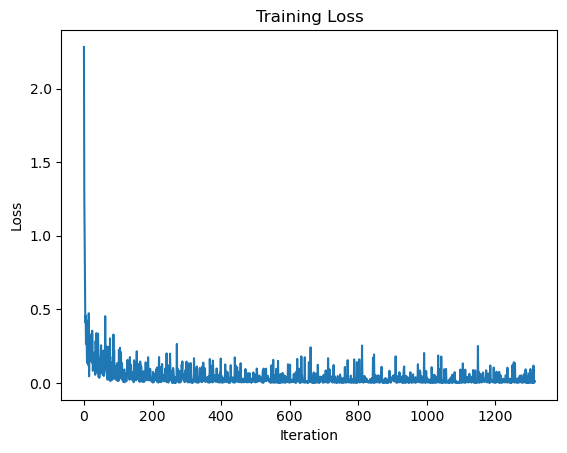

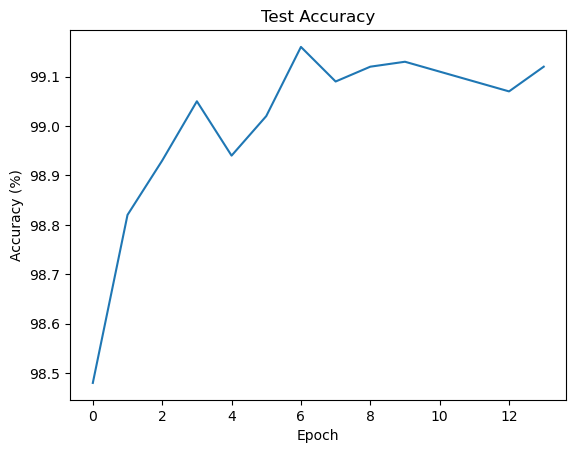

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(accuracies)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()

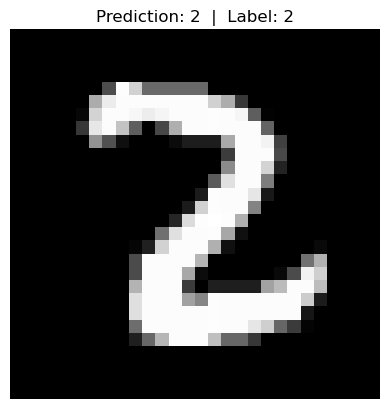

In [10]:
import matplotlib.pyplot as plt

model.eval()

data_iter = iter(test_loader)
images, labels = next(data_iter)

image = images[0].to(device)
label = labels[0]

with torch.no_grad():
    output = model(image.unsqueeze(0))
    prediction = output.argmax(dim=1).item()

plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Prediction: {prediction}  |  Label: {label}")
plt.axis("off")
plt.show()

Une fonctionaliter que j'aurai souhaiter ajouter c'est d'avoir une denetre dans laquel je peut dessiner un nombre et passer ce nombre au modéle. Je souhaiter utiliser deux package pour faire cela ipwidgets et ipycanvas. Mais pour une raison que j'ignore le notebook plante encore et encore sans que je ne sache pourquoi. Je vais tester d'utiliser la version web du notebook jupyter peut être que ça fonctionera mieux et que ca me permetra de regler mes problèmes.